# EDA — CSIC 2010

**Dataset:** HTTP CSIC 2010 — Web Attack Detection
**Objetivo:** Entender la estructura del dataset, detectar problemas de calidad, y definir las features para el Modelo A.
**Archivo:** `../../data/raw/csic2010/csic_database.csv`

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

DATA_PATH = '../../data/raw/csic2010/csic_database.csv'

## 1. Carga y estructura basica

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (61065, 17)


,Unnamed: 0,Method,User-Agent,Pragma,Cache-Control,Accept,Accept-encoding,Accept-charset,language,host,cookie,content-type,connection,lenght,content,classification,URL
0,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=1F767F17239C9B670A39E9B10C3825F4,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/index.jsp HTTP/1.1
1,Normal,GET,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=81761ACA043B0E6014CA42A4BCD06AB5,NaN,close,NaN,NaN,0,http://localhost:8080/tienda1/publico/anadir.jsp?id=3&nombre=Vino+Rioja&prec...
2,Normal,POST,Mozilla/5.0 (compatible; Konqueror/3.5; Linux) KHTML/3.5.8 (like Gecko),no-cache,no-cache,"text/xml,application/xml,application/xhtml+xml,text/html;q=0.9,text/plain;q=...","x-gzip, x-deflate, gzip, deflate","utf-8, utf-8;q=0.5, *;q=0.5",en,localhost:8080,JSESSIONID=933185092E0B668B90676E0A2B0767AF,application/x-www-form-urlencoded,Connection: close,Content-Length: 68,id=3&nombre=Vino+Rioja&precio=100&cantidad=55&B1=A%F1adir+al+carrito,0,http://localhost:8080/tienda1/publico/anadir.jsp HTTP/1.1


In [3]:
df.dtypes

Unnamed: 0           str
Method               str
User-Agent           str
Pragma               str
Cache-Control        str
Accept               str
Accept-encoding      str
Accept-charset       str
language             str
host                 str
cookie               str
content-type         str
connection           str
lenght               str
content              str
classification     int64
URL                  str
dtype: object

## 2. Descripcion de columnas

| Columna | Que es | Util para el modelo |
|---|---|---|
| `Unnamed: 0` | Indice original Normal/Anomalous | No -- redundante |
| `Method` | Metodo HTTP: GET, POST, PUT | Si -- feature categorica |
| `User-Agent` | Identificador del cliente | Probablemente no -- constante |
| `host` | Host destino | No -- constante (localhost:8080) |
| `cookie` | JSESSIONID | Posible -- presencia/ausencia |
| `content` | Body del request | **Muy importante** -- ataques POST |
| `classification` | Label: 0=normal, 1=attack | **Target** |
| `URL` | URL completa | **Muy importante** -- ataques GET |

**Nota:** Los ataques viven en URL (GET) y content (POST).

## 3. El label

In [4]:
print('classification -- valores unicos:', df['classification'].unique())
print('\nDistribucion del label:')
print(df['classification'].value_counts())

classification -- valores unicos: [0 1]

Distribucion del label:
classification
0    36000
1    25065
Name: count, dtype: int64


In [5]:
# Renombrar para claridad
df = df.rename(columns={'classification': 'label'})
print('Label listo:', df['label'].dtype, '-- valores:', df['label'].unique())

Label listo: int64 -- valores: [0 1]


## 4. Distribucion de clases

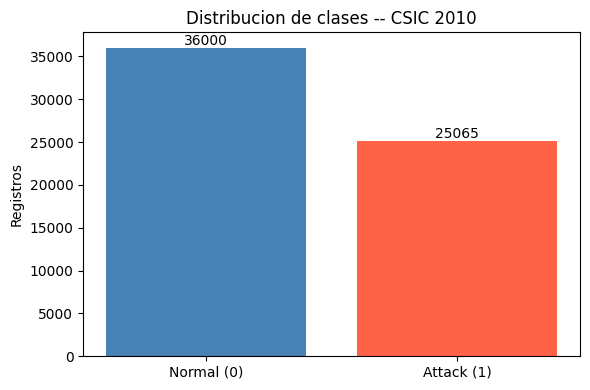

Normal: 36000 (59.0%)
Attack: 25065 (41.0%)

Desbalance: 1.44:1 -- usar class_weight='balanced'


In [6]:
counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Normal (0)', 'Attack (1)'], counts.values, color=['steelblue', 'tomato'])
ax.bar_label(bars, fmt='%d')
ax.set_title('Distribucion de clases -- CSIC 2010')
ax.set_ylabel('Registros')
plt.tight_layout()
plt.show()

print(f'Normal: {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Attack: {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
print(f'\nDesbalance: {counts[0]/counts[1]:.2f}:1 -- usar class_weight=\'balanced\'')

## 5. Nulos por columna

In [7]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(2)
result = pd.DataFrame({'nulos': nulls, 'pct': nulls_pct})
print('Columnas con nulos:')
print(result[nulls > 0])
print('\nNota: content y lenght son NaN en GETs -- esperado, no es problema.')

Columnas con nulos:
              nulos    pct
content       43088  70.56
lenght        43088  70.56
content-type  43088  70.56
Accept          397   0.65

Nota: content y lenght son NaN en GETs -- esperado, no es problema.


## 6. Columnas constantes o de baja variacion

In [8]:
uniqueness = df.nunique().sort_values()
print('Valores unicos por columna:')
print(uniqueness)
print('\nColumnas con 1 solo valor (constantes -- descartar):')
print(uniqueness[uniqueness == 1].index.tolist())

Valores unicos por columna:
language               1
User-Agent             1
Pragma                 1
Cache-Control          1
Accept                 1
Accept-encoding        1
Accept-charset         1
content-type           1
connection             2
Unnamed: 0             2
label                  2
host                   2
Method                 3
lenght               382
content            12091
URL                13505
cookie             61065
dtype: int64

Columnas con 1 solo valor (constantes -- descartar):
['language', 'User-Agent', 'Pragma', 'Cache-Control', 'Accept', 'Accept-encoding', 'Accept-charset', 'content-type']


In [9]:
print('Distribucion de Method (GET/POST/PUT):')
print(df['Method'].value_counts())
print('\nMethod por clase:')
print(pd.crosstab(df['Method'], df['label']))
print('\nPUT = 100% ataques -- la feature mas poderosa del dataset')

Distribucion de Method (GET/POST/PUT):
Method
GET     43088
POST    17580
PUT       397
Name: count, dtype: int64

Method por clase:
label       0      1
Method              
GET     28000  15088
POST     8000   9580
PUT         0    397

PUT = 100% ataques -- la feature mas poderosa del dataset


## 7. Feature engineering -- URL

In [10]:
# Longitud de URL
df['url_length'] = df['URL'].str.len()

print('URL length por clase:')
print(df.groupby('label')['url_length'].describe().round(1))

URL length por clase:
         count   mean   std   min   25%   50%    75%    max
label                                                      
0      36000.0   79.0  59.4  48.0  57.0  58.5   67.0  367.0
1      25065.0  106.6  91.6  31.0  57.0  64.0  122.0  895.0


In [11]:
# Indicadores de ataque en URL
indicators = {
    'pct27': '%27',    # Quote encoded
    'pct3c': '%3C',   # Less-than encoded
    'dashdash': '--',  # SQL comment
    'script': 'script',
    'select': 'select',
}

for name, ind in indicators.items():
    df[f'url_has_{name}'] = df['URL'].str.contains(ind, case=False, regex=False).astype(int)

feature_cols = [c for c in df.columns if c.startswith('url_has_')]
corr = df[feature_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print('Correlacion indicadores URL con label:')
print(corr.round(3))

Correlacion indicadores URL con label:
url_has_pct27       0.183
url_has_dashdash    0.148
url_has_script      0.137
url_has_pct3c       0.124
url_has_select      0.050
Name: label, dtype: float64


## 8. Feature engineering -- content (body POST)

In [12]:
# Solo requests POST tienen content
df_post = df[df['Method'] == 'POST'].copy()
print(f'Requests POST: {len(df_post)} ({len(df_post)/len(df)*100:.1f}% del total)')
print(f'Distribucion label en POSTs:')
print(df_post['label'].value_counts())

# Longitud del body
df['content_length'] = df['content'].str.len().fillna(0)
print('\nContent length por clase:')
print(df.groupby('label')['content_length'].describe().round(1))

Requests POST: 17580 (28.8% del total)
Distribucion label en POSTs:
label
1    9580
0    8000
Name: count, dtype: int64

Content length por clase:
         count  mean   std  min  25%  50%   75%    max
label                                                 
0      36000.0  20.3  59.0  0.0  0.0  0.0   0.0  307.0
1      25065.0  48.6  92.1  0.0  0.0  0.0  62.0  836.0


In [13]:
# Indicadores de ataque en content
df['content_filled'] = df['content'].fillna('')

for name, ind in indicators.items():
    df[f'content_has_{name}'] = df['content_filled'].str.contains(ind, case=False, regex=False).astype(int)

content_cols = [c for c in df.columns if c.startswith('content_has_')]
corr_content = df[content_cols + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print('Correlacion indicadores content con label:')
print(corr_content.round(3))

Correlacion indicadores content con label:
content_has_pct27       0.183
content_has_dashdash    0.148
content_has_script      0.126
content_has_pct3c       0.124
content_has_select      0.048
Name: label, dtype: float64


## 9. Hallazgos clave

### Label
- `classification` ya esta en 0/1 -- sin transformacion necesaria
- `Unnamed: 0` tiene Normal/Anomalous pero es redundante

### Distribucion de clases
- **Normal (0):** 36,000 (59%)
- **Attack (1):** 25,065 (41%)
- Desbalance leve -- usar `class_weight='balanced'`

### Metodos HTTP
- **GET:** 43,088 -- tasa de ataque 35%
- **POST:** 17,580 -- tasa de ataque 54%
- **PUT:** 397 -- tasa de ataque **100%** <- feature mas poderosa

### Nulos
- `content`, `lenght`, `content-type`: 70.56% nulos en GETs -- esperado
- `Accept`: 0.65% nulos -- columna constante

### Columnas a descartar (constantes)
- `language`, `User-Agent`, `Pragma`, `Cache-Control`, `Accept`, `Accept-encoding`, `Accept-charset`, `content-type`

### Features mas prometedoras
- `method_is_put` -> correlacion perfecta (100% ataques)
- `url_has_pct27`, `url_has_dashdash`, `url_has_script`, `url_has_pct3c`
- `url_length`, `content_length`
- Los atacantes usan URL encoding (`%27`, `%3C`) -- nunca chars literales

### Decisiones para preprocessing
- Descartar 11 columnas constantes
- Construir features binarias de URL-encoding
- `content_length = 0` para GETs (no NaN)
- One-hot encode Method: GET/POST/PUT
- Solo normalizar `url_length` y `content_length`